# Breast Cancer Classification Project
### Breast cancer diagnosis involves distinguishing between benign (B) and malignant (M) tissue samples. In this project, we will use ML to learn patterns from numerical measurements of breast-cell nuclei and classify a sample as either benign or malignant.

## Step 1: Load the Dataset
### 1.1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2: Load the CSV file

In [2]:
df = pd.read_csv("BreastCancer.csv")

In [3]:
#understand dataset using first five rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
#shape of the data
df.shape

(569, 33)

## Step 2: Understand the Dataset

In [5]:
#column names
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [6]:
#check data types
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [7]:
#check for null values
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [8]:
##Check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [9]:
##Check the Diagnosis Values
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

#### Note : Dataset contains more benign than malignant samples. This is called class imbalance.

In [10]:
##Check the Target Proportions
df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

#### Note : About 63% of the samples are benign and 37% are malignant.

In [11]:
##Inspect the Numerical Features
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [12]:
##Check the Feature Scales
df.describe().T[["min", "max", "mean", "std"]]

,min,max,mean,std
id,8670.000000,9.113205e+08,3.037183e+07,1.250206e+08
radius_mean,6.981000,2.811000e+01,1.412729e+01,3.524049e+00
texture_mean,9.710000,3.928000e+01,1.928965e+01,4.301036e+00
perimeter_mean,43.790000,1.885000e+02,9.196903e+01,2.429898e+01
area_mean,143.500000,2.501000e+03,6.548891e+02,3.519141e+02
smoothness_mean,0.052630,1.634000e-01,9.636028e-02,1.406413e-02
compactness_mean,0.019380,3.454000e-01,1.043410e-01,5.281276e-02
concavity_mean,0.000000,4.268000e-01,8.879932e-02,7.971981e-02
concave points_mean,0.000000,2.012000e-01,4.891915e-02,3.880284e-02
symmetry_mean,0.106000,3.040000e-01,1.811619e-01,2.741428e-02


In [13]:
##Check the id Column
df["id"].nunique()

569

In [14]:
#Check the Actual Feature Names
df.columns[2:-1]

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

## Step 3: Data Cleaning

In [15]:
#Remove the Empty Column
df = df.drop(columns=["Unnamed: 32"])
df.shape

(569, 32)

In [16]:
#Understand Before Removing id
df.groupby("diagnosis")["id"].agg(["min", "max"])

,min,max
diagnosis,,
B,8913,911320502
M,8670,911296202


#### Note: The ID ranges overlap heavily between the two diagnosis groups, So there is no clean ID range separating benign and malignant samples.

In [17]:
#Remove id
df=df.drop(columns=["id"])

In [18]:
df.shape

(569, 31)

In [19]:
#Check the Clean Dataset
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

## Step 4: Exploratory Data Analysis (EDA)
### 4.1: Separate Features and Target

In [20]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

### 4.2: Understand Feature Distributions

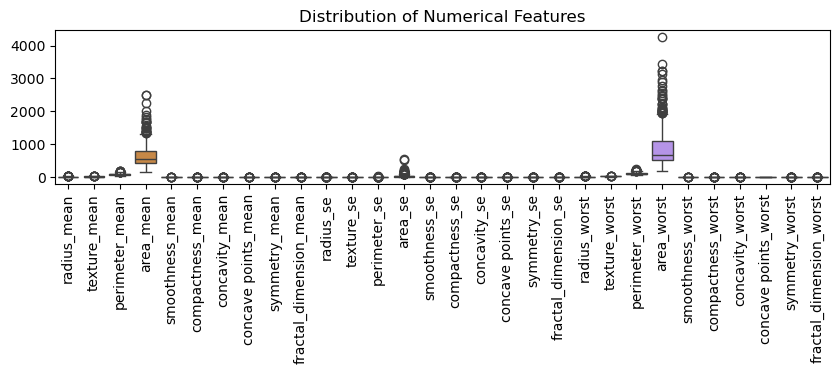

In [21]:
plt.figure(figsize=(10, 2))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title("Distribution of Numerical Features")
plt.show()

### 4.3: Compare Features by Diagnosis

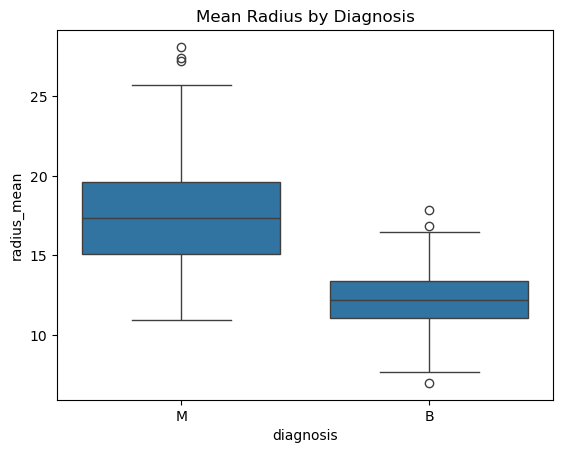

In [22]:
sns.boxplot(x="diagnosis", y="radius_mean", data=df)
plt.title("Mean Radius by Diagnosis")
plt.show()

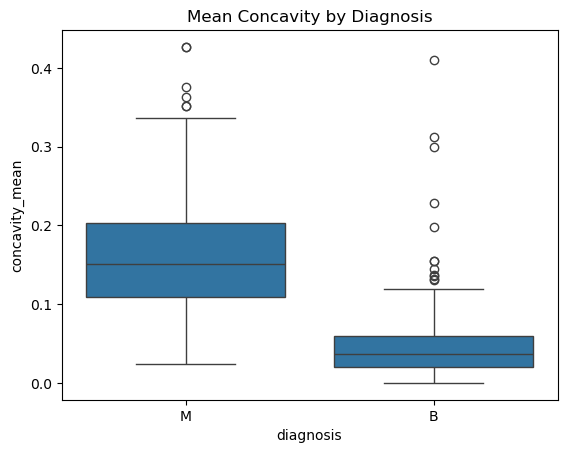

In [23]:
sns.boxplot(x="diagnosis", y="concavity_mean", data=df)
plt.title("Mean Concavity by Diagnosis")
plt.show()

### 4.4: Class Distribution

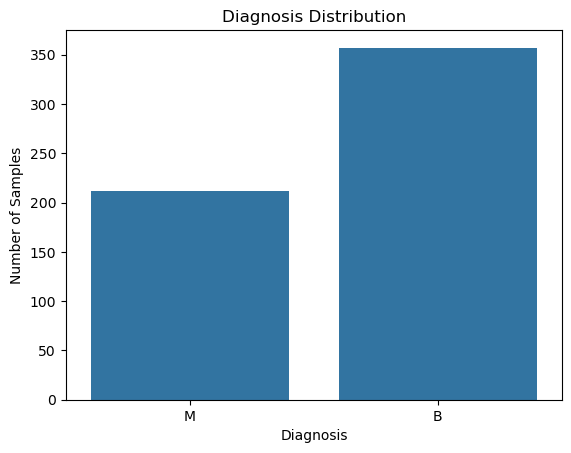

In [24]:
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()

### 4.5: Correlation Analysis

In [25]:
correlation = X.corr()

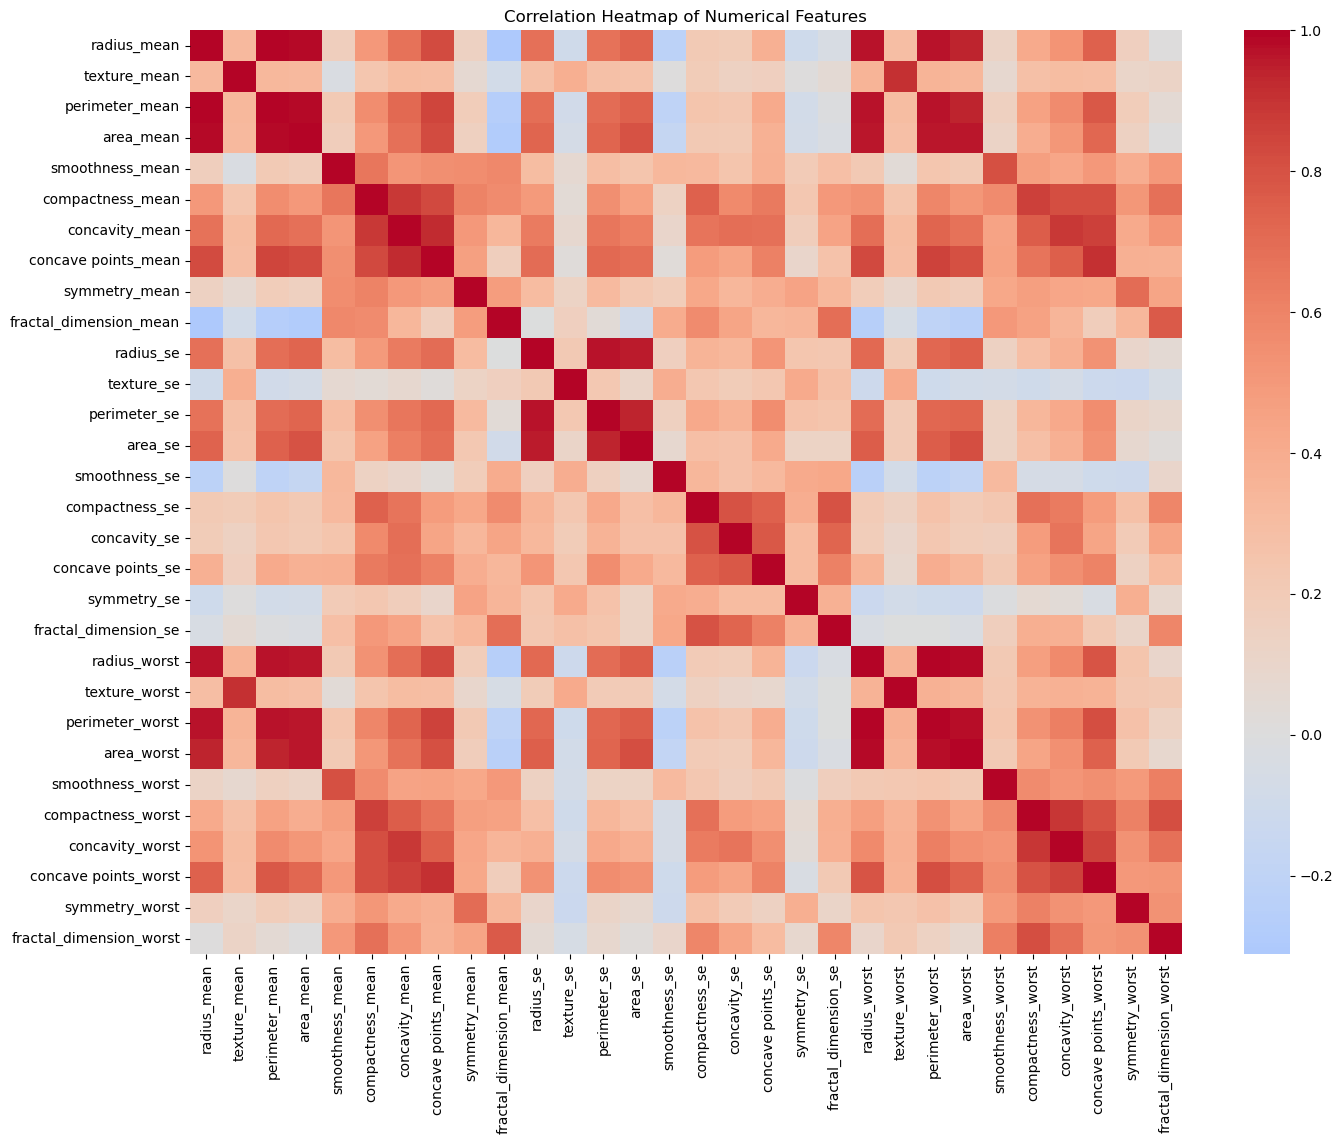

In [26]:
##Correlation Heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [27]:
corr_pairs = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)

corr_pairs.head(10)

radius_mean      perimeter_mean     0.997855
radius_worst     perimeter_worst    0.993708
radius_mean      area_mean          0.987357
perimeter_mean   area_mean          0.986507
radius_worst     area_worst         0.984015
perimeter_worst  area_worst         0.977578
radius_se        perimeter_se       0.972794
perimeter_mean   perimeter_worst    0.970387
radius_mean      radius_worst       0.969539
perimeter_mean   radius_worst       0.969476
dtype: float64

### 4.6: Correlation With the Target

In [28]:
df["diagnosis_num"] = df["diagnosis"].map({"B": 0, "M": 1})

In [29]:
target_corr = df.corr(numeric_only=True)["diagnosis_num"].drop("diagnosis_num").sort_values(
    key=abs, ascending=False
)

target_corr.head(10)

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis_num, dtype: float64

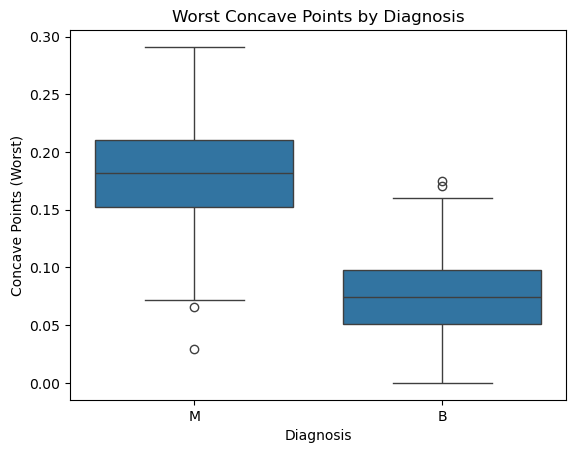

In [30]:
sns.boxplot(x="diagnosis", y="concave points_worst", data=df)

plt.title("Worst Concave Points by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Concave Points (Worst)")
plt.show()

In [31]:
top_features = target_corr.head(5).index

df[top_features].corr()

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean
concave points_worst,1.000000,0.816322,0.910155,0.787424,0.771241
perimeter_worst,0.816322,1.000000,0.855923,0.993708,0.970387
concave points_mean,0.910155,0.855923,1.000000,0.830318,0.850977
radius_worst,0.787424,0.993708,0.830318,1.000000,0.969476
perimeter_mean,0.771241,0.970387,0.850977,0.969476,1.000000


### 4.7: check feature distributions(skewness)

In [32]:
skewness = X.skew().sort_values(ascending=False)

skewness.head(10)

area_se                    5.447186
concavity_se               5.110463
fractal_dimension_se       3.923969
perimeter_se               3.443615
radius_se                  3.088612
smoothness_se              2.314450
symmetry_se                2.195133
compactness_se             1.902221
area_worst                 1.859373
fractal_dimension_worst    1.662579
dtype: float64

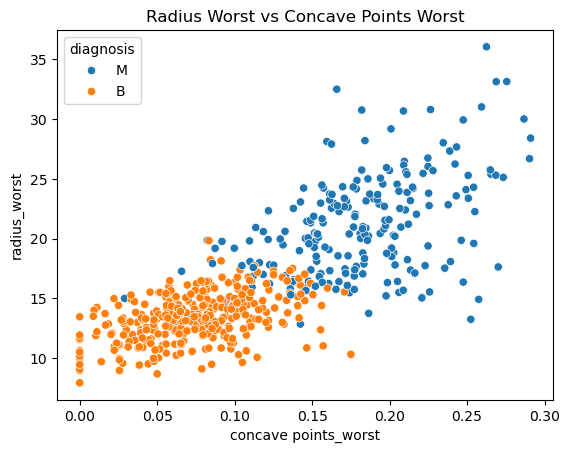

In [33]:
sns.scatterplot(
    data=df,
    x="concave points_worst",
    y="radius_worst",
    hue="diagnosis"
)

plt.title("Radius Worst vs Concave Points Worst")
plt.show()

## Step 5: Prepare Data for Machine Learning
### 5.1: Remove the temporary analysis column

In [34]:
df = df.drop(columns=["diagnosis_num"])

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

### 5.2: Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 5.3: Check the split

In [36]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train shape: (455, 30)
X_test shape: (114, 30)

y_train distribution:
diagnosis
B    285
M    170
Name: count, dtype: int64

y_test distribution:
diagnosis
B    72
M    42
Name: count, dtype: int64


### Step 5.4: Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
print("First 5 rows of scaled training data:")
print(X_train_scaled[:5])

print("\nMean of scaled training data:")
print(X_train_scaled.mean())

print("\nStandard deviation of scaled training data:")
print(X_train_scaled.std())

First 5 rows of scaled training data:
[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 -6.31833818e-01 -6.04281166e-01 -3.03074908e-01
   5.21543093e-01 -4.54522896e-01 -6.04377961e-01 -1.00104604e+00
  -5.85429002e-01 -4.93453793e-01  4.03212009e-01 -7.68173276e-01
  -4.79187222e-01  1.14508478e-01 -1.42950761e-01 -5.77397732e-01
  -5.82458953e-01 -1.69029101e+00 -6.11934288e-01 -5.87013537e-01
   2.73581959e-01 -8.14844486e-01 -7.12666415e-01 -3.23207881e-01
  -

#### Note: The training features have been standardized successfully, with mean approximately 0 and standard deviation 1.

## Step 6: ML Baseline Models
### Step 6.1: Model 1 - Logistic Regression Model

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
logistic_model = LogisticRegression(random_state=42)

In [41]:
#Train Logistic Regression
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
#Make predictions
y_pred = logistic_model.predict(X_test_scaled)

print(y_pred[:20])

['B' 'M' 'B' 'M' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B'
 'B' 'B']


In [43]:
#Compare predictions with actual values
print("Predicted:", y_pred[:20])
print("Actual:   ", y_test[:20].values)

Predicted: ['B' 'M' 'B' 'M' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B'
 'B' 'B']
Actual:    ['B' 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B'
 'B' 'B']


In [44]:
#Calculate Test Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9649122807017544


In [45]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[71  1]
 [ 3 39]]


#### Note: TN = 71, FP = 1, FN = 3 and TP = 39

In [46]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [47]:
train_accuracy_logistic = logistic_model.score(X_train_scaled, y_train)
test_accuracy_logistic = logistic_model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy_logistic)
print("Testing Accuracy:", test_accuracy_logistic)

Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.9649122807017544


### 6.2: Model 2 - Decision Tree Classifier

In [48]:
#import decision tree
from sklearn.tree import DecisionTreeClassifier

In [49]:
#create decision tree
decision_tree = DecisionTreeClassifier(random_state=42)

In [50]:
#Train the Decision Tree
decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [51]:
#Make predictions
y_pred_tree = decision_tree.predict(X_test)

print(y_pred_tree[:20])

['B' 'M' 'M' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B'
 'B' 'B']


In [52]:
#Compare preditions
print("Predicted:", y_pred_tree[:20])
print("Actual:   ", y_test[:20].values)

Predicted: ['B' 'M' 'M' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B'
 'B' 'B']
Actual:    ['B' 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B'
 'B' 'B']


In [53]:
#Test Accuracy
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Test Accuracy:", tree_accuracy)

Decision Tree Test Accuracy: 0.9298245614035088


In [54]:
#Decision Tree Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[68  4]
 [ 4 38]]


#### Note: TN = 68, FP = 4, FN = 4 & TP = 38

In [55]:
#Classification Report
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           B       0.94      0.94      0.94        72
           M       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



#### Note: 
##### The Decision Tree achieved 92.98% test accuracy. It correctly classified 68 benign and 38 malignant cases. It produced 4 false positives and 4 false negatives. For malignant cases, it achieved 90% precision, 90% recall, and 90% F1-score.

In [56]:
#training vs testing accuracy
train_accuracy_tree = decision_tree.score(X_train, y_train)
test_accuracy_tree = decision_tree.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_tree)
print("Testing Accuracy:", test_accuracy_tree)

Training Accuracy: 1.0
Testing Accuracy: 0.9298245614035088


### Overfitting comparison

| Model                   | Training Accuracy | Testing Accuracy |    Gap |
| ----------------------- | ----------------: | ---------------: | -----: |
| **Logistic Regression** |            98.68% |       **96.49%** | ~2.19% |
| **Decision Tree**       |              100% |       **92.98%** | ~7.02% |


### 6.3: Model 3- K-Nearest Neighbors (KNN)

In [57]:
#Import KNN
from sklearn.neighbors import KNeighborsClassifier

In [58]:
#Create the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

In [59]:
#Train KNN
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [60]:
#Make KNN predictions
y_pred_knn = knn_model.predict(X_test_scaled)

print(y_pred_knn[:20])

['B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B'
 'M' 'B']


In [61]:
#Compare
print("Predicted:", y_pred_knn[:20])
print("Actual:   ", y_test[:20].values)

Predicted: ['B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B'
 'M' 'B']
Actual:    ['B' 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B'
 'B' 'B']


In [62]:
#Test Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Test Accuracy:", knn_accuracy)

KNN Test Accuracy: 0.956140350877193


In [63]:
#KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[71  1]
 [ 4 38]]


#### Note: TN = 71, FP = 1, FN = 4 and TP =38 

In [64]:
#KNN Classification Report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [65]:
#training vs testing accuracy
train_accuracy_knn = knn_model.score(X_train_scaled, y_train)
test_accuracy_knn = knn_model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy_knn)
print("Testing Accuracy:", test_accuracy_knn)

Training Accuracy: 0.978021978021978
Testing Accuracy: 0.956140350877193


#### Note:
##### KNN achieved 97.80% training accuracy and 95.61% testing accuracy, with an accuracy gap of approximately 2.19 percentage points. The small gap suggests that the baseline KNN model is not strongly overfitting.

### Comparison
| Model               | Training Accuracy | Testing Accuracy |       Gap |
| ------------------- | ----------------: | ---------------: | --------: |
| Logistic Regression |            98.68% |           96.49% | **2.19%** |
| Decision Tree       |              100% |           92.98% | **7.02%** |
| KNN                 |            97.80% |           95.61% | **2.19%** |


### 6.4: Model 4 - SVM (Support Vector Machine)

In [66]:
# Import SVM
from sklearn.svm import SVC

In [67]:
#Create the SVM model
svm_model = SVC(random_state=42)

In [68]:
#Train the SVM
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [69]:
#Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)
print(y_pred_svm[:20])

['B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B'
 'B' 'B']


In [70]:
print(y_test[:20].values)

['B' 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B'
 'B' 'B']


In [71]:
#Test accuracy
test_accuracy_svm = svm_model.score(X_test_scaled, y_test)

print("Testing Accuracy:", test_accuracy_svm)

Testing Accuracy: 0.9736842105263158


In [72]:
#Training accuracy
train_accuracy_svm = svm_model.score(X_train_scaled, y_train)

print("Training Accuracy:", train_accuracy_svm)

Training Accuracy: 0.9868131868131869


In [73]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

[[72  0]
 [ 3 39]]


#### Note: 
##### TN = 72 → B correctly predicted as B
##### FP = 0 → B incorrectly predicted as M
##### FN = 3 → M incorrectly predicted as B
##### TP = 39 → M correctly predicted as M

In [74]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### Comparison
| Model               | Train Acc. |  Test Acc. |       Gap |    FP |    FN |
| ------------------- | ---------: | ---------: | --------: | ----: | ----: |
| Logistic Regression |     98.68% |     96.49% |     2.19% |     1 |     3 |
| Decision Tree       |       100% |     92.98% |     7.02% |     4 |     4 |
| KNN                 |     97.80% |     95.61% |     2.19% |     1 |     4 |
| **SVM**             | **98.68%** | **97.36%** | **1.32%** | **0** | **3** |


## Step 7: Model Comparison
### 7.1: Create the comparison table

In [75]:
model_comparison = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "SVM"
    ],
    "Training Accuracy": [
        0.9868,
        1.0000,
        0.9780,
        0.9868
    ],
    "Testing Accuracy": [
        0.9649,
        0.9298,
        0.9561,
        0.9736
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(model_comparison)

comparison_df

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.9868,0.9649
1,Decision Tree,1.0000,0.9298
2,KNN,0.9780,0.9561
3,SVM,0.9868,0.9736


### 7.2: Accuracy gap

In [76]:
accuracy_gaps = {
    "Logistic Regression": (0.9868 - 0.9649),
    "Decision Tree": (1.0000 - 0.9298),
    "KNN": (0.9780 - 0.9561),
    "SVM": (0.9868 - 0.9736)
}

for model, gap in accuracy_gaps.items():
    print(model, "gap:", round(gap * 100, 2), "%")

Logistic Regression gap: 2.19 %
Decision Tree gap: 7.02 %
KNN gap: 2.19 %
SVM gap: 1.32 %


In [77]:
comparison_metrics = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN", "SVM"],
    "Accuracy": [0.9649, 0.9298, 0.9561, 0.9736],
    "M Recall": [0.93, 0.90, 0.90, 0.93],
    "M F1": [0.95, 0.90, 0.94, 0.96],
    "FN": [3, 4, 4, 3]
})

comparison_metrics

,Model,Accuracy,M Recall,M F1,FN
0,Logistic Regression,0.9649,0.93,0.95,3
1,Decision Tree,0.9298,0.90,0.90,4
2,KNN,0.9561,0.90,0.94,4
3,SVM,0.9736,0.93,0.96,3


## Step 8: Tune the models

### 8.1: Logistic Regression

In [78]:
logistic_model_tuned = LogisticRegression(
    C=0.1,
    random_state=42
)

logistic_model_tuned.fit(X_train_scaled, y_train)

logistic_tuned_accuracy = logistic_model_tuned.score(
    X_test_scaled, y_test
)

print("Tuned Logistic Regression Accuracy:",
      round(logistic_tuned_accuracy * 100, 2), "%")

Tuned Logistic Regression Accuracy: 98.25 %


In [79]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_logistic_tuned = logistic_model_tuned.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_logistic_tuned))
print(classification_report(y_test, y_pred_logistic_tuned))

[[72  0]
 [ 2 40]]
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### Result: Tuning improved the model compared with the baseline. Accuracy increased by 1.76 percentage points, and FN decreased from 3 → 2.

### 8.2: Tune Decision Tree

In [81]:
decision_tree_tuned = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree_tuned.fit(X_train, y_train)

decision_tree_tuned_accuracy = decision_tree_tuned.score(
    X_test, y_test
)

print(
    "Tuned Decision Tree Accuracy:",
    round(decision_tree_tuned_accuracy * 100, 2),
    "%"
)

Tuned Decision Tree Accuracy: 92.11 %


In [82]:
y_pred_tree_tuned = decision_tree_tuned.predict(X_test)

print(confusion_matrix(y_test, y_pred_tree_tuned))

[[70  2]
 [ 7 35]]


#### Result: tuning with max_depth=5 made the model worse.

### 8.3: Tune KNN

In [83]:
knn_tuned = KNeighborsClassifier(n_neighbors=7)

knn_tuned.fit(X_train_scaled, y_train)

knn_tuned_accuracy = knn_tuned.score(
    X_test_scaled, y_test
)

print(
    "Tuned KNN Accuracy:",
    round(knn_tuned_accuracy * 100, 2),
    "%"
)

Tuned KNN Accuracy: 95.61 %


In [84]:
y_pred_knn_tuned = knn_tuned.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_knn_tuned))

[[71  1]
 [ 4 38]]


#### Result: No improvement.

### 8.4: Tune SVM

In [85]:
svm_tuned = SVC(
    C=10,
    random_state=42
)

svm_tuned.fit(X_train_scaled, y_train)

svm_tuned_accuracy = svm_tuned.score(
    X_test_scaled, y_test
)

print(
    "Tuned SVM Accuracy:",
    round(svm_tuned_accuracy * 100, 2),
    "%"
)

Tuned SVM Accuracy: 97.37 %


In [86]:
y_pred_svm_tuned = svm_tuned.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_svm_tuned))

[[72  0]
 [ 3 39]]


#### Result: Practically no improvement.

### 8.5: Comparison of tuned models

In [87]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "SVM"
    ],
    "Baseline Accuracy": [
        96.49, 92.98, 95.61, 97.36
    ],
    "Tuned Accuracy": [
        98.25, 92.11, 95.61, 97.37
    ]
})

final_comparison

,Model,Baseline Accuracy,Tuned Accuracy
0,Logistic Regression,96.49,98.25
1,Decision Tree,92.98,92.11
2,KNN,95.61,95.61
3,SVM,97.36,97.37


### 8.6: Final model evaluation

In [88]:
print(classification_report(
    y_test,
    y_pred_logistic_tuned
))

              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Step 9: Test the final model on a new sample

In [89]:
sample = X_test.iloc[0].values.reshape(1, -1)

sample_scaled = scaler.transform(sample)

prediction = logistic_model_tuned.predict(sample_scaled)

print("Predicted:", prediction[0])
print("Actual:", y_test.iloc[0])

Predicted: B
Actual: B


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [90]:
probability = logistic_model_tuned.predict_proba(sample_scaled)

print("Probability of B:", round(probability[0][0] * 100, 2), "%")
print("Probability of M:", round(probability[0][1] * 100, 2), "%")

Probability of B: 99.43 %
Probability of M: 0.57 %


## Step 10: Save the final model

In [91]:
import joblib

joblib.dump(logistic_model_tuned, "breast_cancer_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [92]:
loaded_model = joblib.load("breast_cancer_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

test_sample = X_test.iloc[0].values.reshape(1, -1)
test_sample_scaled = loaded_scaler.transform(test_sample)

loaded_prediction = loaded_model.predict(test_sample_scaled)

print("Loaded model prediction:", loaded_prediction[0])
print("Actual:", y_test.iloc[0])

Loaded model prediction: B
Actual: B


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Conclusion:
#### In this project, a breast cancer classification model was developed using the Wisconsin Diagnostic Breast Cancer dataset. Several machine learning algorithms were trained and evaluated, including Logistic Regression, Decision Tree, KNN, and SVM.
#### After model tuning, Logistic Regression achieved an accuracy of 98.25% on the test set. It correctly classified 112 out of 114 test samples, with 2 false negatives.
#### The tuned Logistic Regression model was selected as the final model for this project. The model and the StandardScaler were also saved using Joblib and successfully loaded again to verify that the trained model could be reused for future predictions.
### The results are based on this dataset and test split and should not be considered a substitute for clinical diagnosis or validation.